In [18]:
import os

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import yfinance as yf

Financial reverse engineering

Multi time correlation function (Scully, Zubairy; Optics, Chatper 4) between AMD and MU -- they are trying to lock this down

In [19]:
symbols = [
    # "^DJI",
    # "^GSPC"
    "AMD",
    "MU",
]

START = "2024-01-01"
END = None

signal = yf.download(symbols,  start=START, end=END)["Close"].dropna()

AMD = signal[symbols[0]]

MU = signal[symbols[-1]]

def correlation(m, n):
  return np.corrcoef(m, n)[0][1]

/tmp/ipython-input-367761095.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  signal = yf.download(symbols,  start=START, end=END)["Close"].dropna()
[*********************100%***********************]  2 of 2 completed


In [20]:
signal

Ticker,AMD,MU
Date,,
2024-01-02,138.580002,81.754936
2024-01-03,135.320007,81.675514
2024-01-04,136.009995,82.122314
2024-01-05,138.580002,82.857048
2024-01-08,146.179993,84.346397
...,...,...
2025-11-17,240.520004,241.949997
2025-11-18,230.289993,228.500000
2025-11-19,223.550003,225.919998


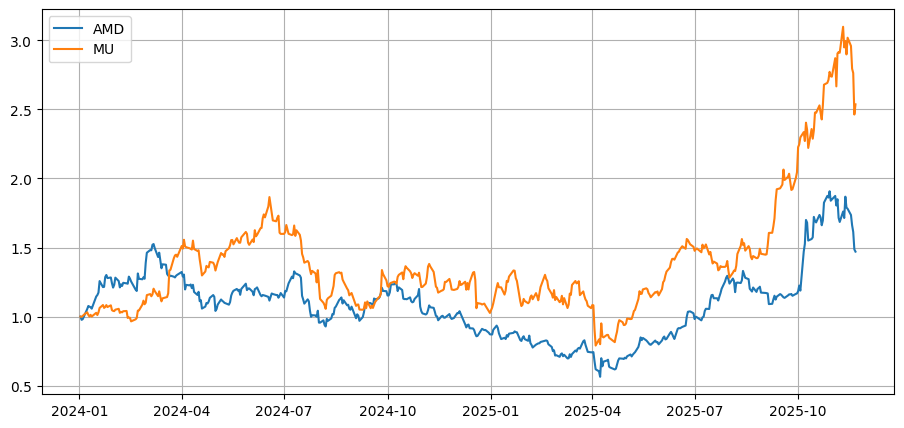

In [21]:
plt.figure(figsize=(11, 5))
plt.plot(signal / signal.iloc[0], label=signal.columns)
plt.legend()
plt.grid()
plt.show()

In [22]:
M = 50

CDS = dict(zip(range(1, M + 1), [None] * (M + 1)))
CSD = dict(zip(range(1, M + 1), [None] * (M + 1)))

PSD = CSD.copy()
PDS = CDS.copy()

for m in CSD.keys():
  l = 0
  spread_days = np.linspace(5 * m, 5 * (m + 1), 6).astype(int)
  window_days = spread_days.copy()

  CDS[m] = []
  CSD[m] = []

  PDS[m] = []
  PSD[m] = []

  for i in range(signal.shape[0]):
    # faster to calculate all in advance
    # this was a step taken from another version
    for spread in spread_days:
      if 2 * (i + spread) >= AMD.shape[0] + MU.shape[0]:
        break

      for w in window_days:
        x, y, q, z = (
            np.array(AMD.iloc[i: i + w]),
            np.array(MU.iloc[i: i + w]),
            np.array(AMD.iloc[i + spread: i + spread + w]),
            np.array(MU.iloc[i + spread: i + spread + w]),
        )

        if w > spread:
          break

        if len(x) + len(y) + len(z) + len(q) != 4 * w:
          break

        c_ = correlation(x, z)
        CDS[m].append(c_)

        sign = np.sign(x[-1] / x[0] - 1)
        if spread > 100:
          sign *= -1 # depends on time
          # pass

        p_ = (1 + (z[-1] / z[0] - 1) * sign) ** (250 / w) - 1
        if not np.isnan(p_):
          PDS[m].append(p_)

        c_ = correlation(y, q)
        CSD[m].append(c_)

        sign = np.sign(y[-1] / y[0] - 1)
        if spread > 70:
          sign *= -1

        p_ = (1 + (q[-1] / q[0] - 1) * sign) ** (250 / w) - 1
        if not np.isnan(p_):
          PSD[m].append(p_)

/tmp/ipython-input-1575755132.py:60: RuntimeWarning: invalid value encountered in scalar power
  p_ = (1 + (q[-1] / q[0] - 1) * sign) ** (250 / w) - 1
/tmp/ipython-input-1575755132.py:49: RuntimeWarning: invalid value encountered in scalar power
  p_ = (1 + (z[-1] / z[0] - 1) * sign) ** (250 / w) - 1


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-2374014922.py:4: RuntimeWarning: invalid value encountered in scalar divide
  edges = [(np.array(CSD[k]) > 0).sum() / len(CSD[k]) for k in CSD]


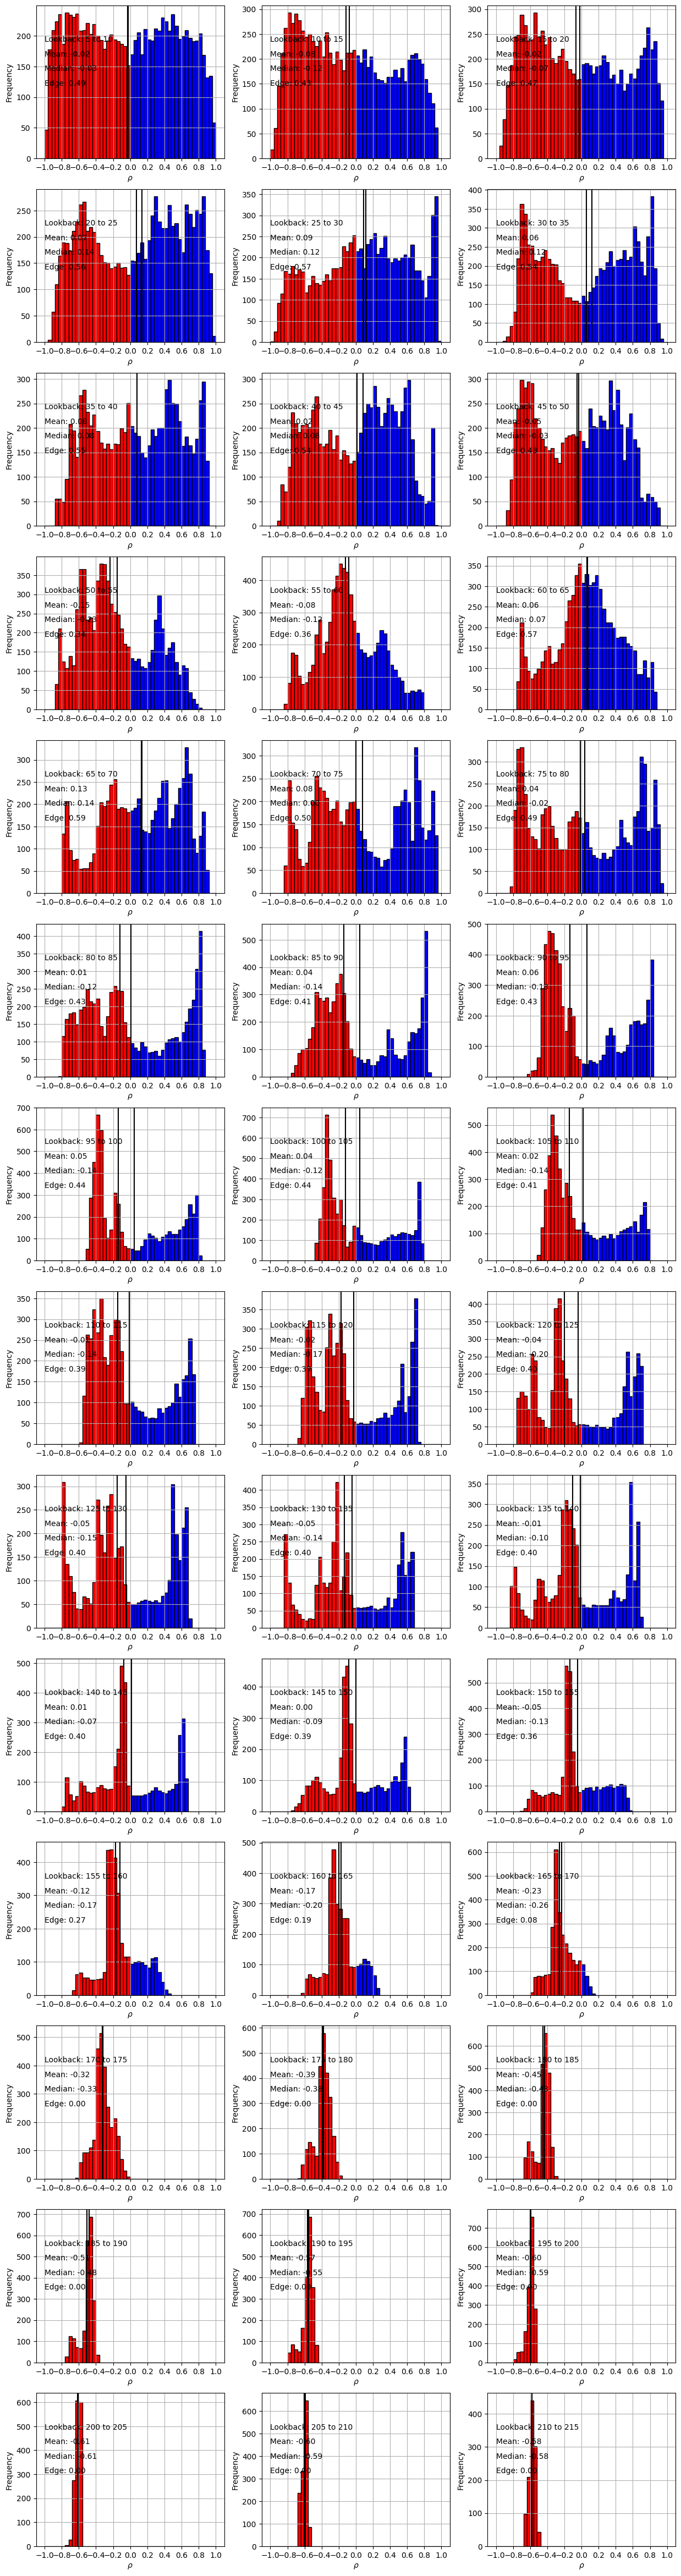

In [23]:
fig, axes = plt.subplots(14, 3, figsize=(15, 60))
medians = [np.median(CSD[k]) for k in CSD]
means = [np.mean(CSD[k]) for k in CSD]
edges = [(np.array(CSD[k]) > 0).sum() / len(CSD[k]) for k in CSD]
edge_min, edge_max = np.max(edges), np.max(edges)
median_min, median_max = np.min(medians), np.max(medians)
mean_min, mean_max = np.min(means), np.max(means)
for i in range(14):
  for j in range(3):
    k = i * 3 + j + 1
    # bins = np.linspace(0, min(10, np.max(C[k]) * 1.01), 11)
    bins = np.linspace(-1, 1, 51)
    x, y, z = axes[i][j].hist(CSD[k], bins=bins, edgecolor='black')
    for l in range(len(z)):
      if l < len(z) // 2:
        z[l].set_facecolor("r")
      else:
        z[l].set_facecolor("b")

    c_mean = "b" if means[k - 1] == mean_max else ("r" if means[k - 1] == mean_min else "k")
    c_median = "b" if medians[k - 1] == median_max else ("r" if medians[k - 1] == median_min else "k")
    c_edge = "b" if edges[k - 1] == edge_max else ("r" if edges[k - 1] == edge_min else "k")

    axes[i][j].axvline(np.median(CSD[k]), color="k")
    axes[i][j].axvline(np.mean(CSD[k]), color="k")
    axes[i][j].text(bins[0], 0.8 * x.max(), f"Lookback: {5 * k} to {5 * (k + 1)}")
    axes[i][j].text(bins[0], 0.5 * x.max(), f"Edge: {edges[k - 1]:.2f}", color=c_edge)
    axes[i][j].text(bins[0], 0.7 * x.max(), f"Mean: {means[k - 1]:.2f}", color=c_mean)
    axes[i][j].text(bins[0], 0.6 * x.max(), f"Median: {medians[k - 1]:.2f}", color=c_median)
    axes[i][j].set_xticks(bins[::5])
    axes[i][j].set_ylabel("Frequency")
    # axes[i][j].set_xlabel("$P$")
    axes[i][j].set_xlabel("$\\rho$")
    axes[i][j].grid()
plt.show()

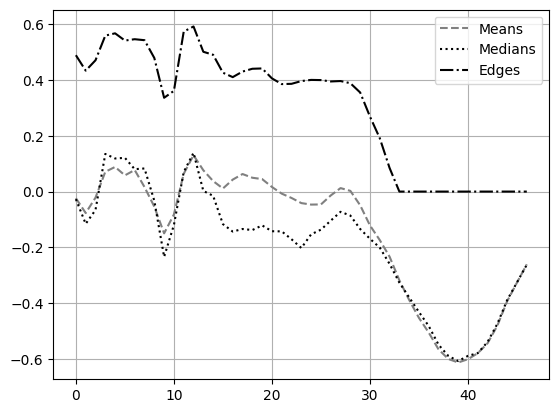

In [24]:
plt.plot(means, "--", color='gray', label="Means")
plt.plot(medians, ":", color="black", label="Medians")
plt.plot(edges, "-.", color="black", label="Edges")
plt.grid()
plt.legend()
plt.show()
# frequency = 20

/tmp/ipython-input-414868260.py:4: RuntimeWarning: invalid value encountered in scalar divide
  edges = [(np.array(CDS[k]) > 0).sum() / len(CDS[k]) for k in CDS]


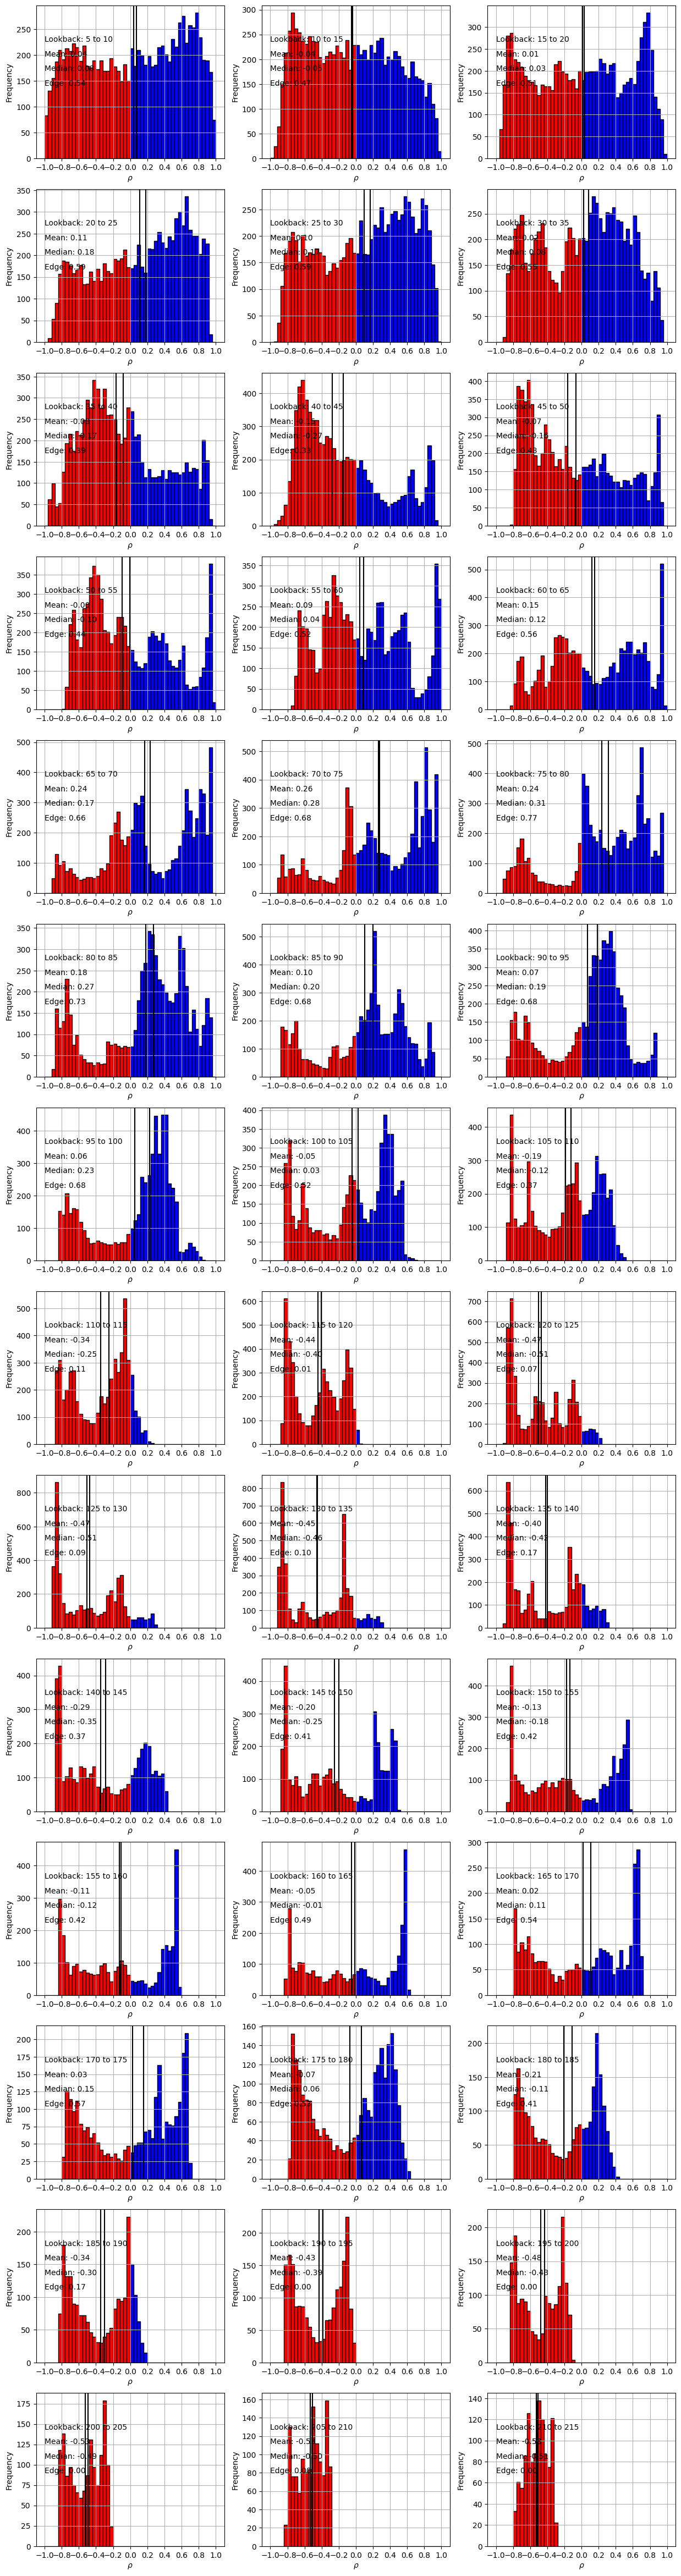

In [25]:
fig, axes = plt.subplots(14, 3, figsize=(15, 60))
medians = [np.median(CDS[k]) for k in CSD]
means = [np.mean(CDS[k]) for k in CSD]
edges = [(np.array(CDS[k]) > 0).sum() / len(CDS[k]) for k in CDS]
edge_min, edge_max = np.max(edges), np.max(edges)
median_min, median_max = np.min(medians), np.max(medians)
mean_min, mean_max = np.min(means), np.max(means)
for i in range(14):
  for j in range(3):
    k = i * 3 + j + 1
    # bins = np.linspace(0, min(10, np.max(C[k]) * 1.01), 11)
    bins = np.linspace(-1, 1, 51)
    x, y, z = axes[i][j].hist(CDS[k], bins=bins, edgecolor='black')
    for l in range(len(z)):
      if l < len(z) // 2:
        z[l].set_facecolor("r")
      else:
        z[l].set_facecolor("b")

    c_mean = "b" if means[k - 1] == mean_max else ("r" if means[k - 1] == mean_min else "k")
    c_median = "b" if medians[k - 1] == median_max else ("r" if medians[k - 1] == median_min else "k")
    c_edge = "b" if edges[k - 1] == edge_max else ("r" if edges[k - 1] == edge_min else "k")

    axes[i][j].axvline(np.median(CDS[k]), color="k")
    axes[i][j].axvline(np.mean(CDS[k]), color="k")
    axes[i][j].text(bins[0], 0.8 * x.max(), f"Lookback: {5 * k} to {5 * (k + 1)}")
    axes[i][j].text(bins[0], 0.5 * x.max(), f"Edge: {edges[k - 1]:.2f}", color=c_edge)
    axes[i][j].text(bins[0], 0.7 * x.max(), f"Mean: {means[k - 1]:.2f}", color=c_mean)
    axes[i][j].text(bins[0], 0.6 * x.max(), f"Median: {medians[k - 1]:.2f}", color=c_median)
    axes[i][j].set_xticks(bins[::5])
    axes[i][j].set_ylabel("Frequency")
    # axes[i][j].set_xlabel("$P$")
    axes[i][j].set_xlabel("$\\rho$")
    axes[i][j].grid()
plt.show()


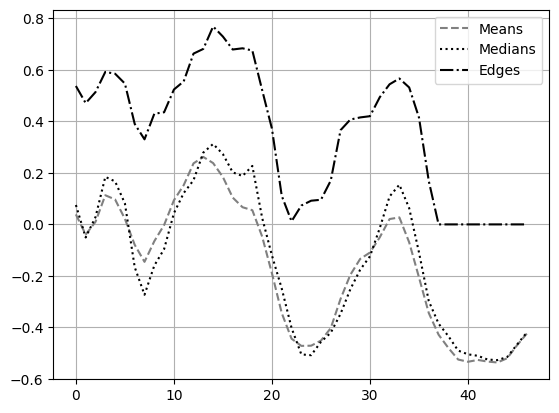

In [26]:
plt.plot(means, "--", color='gray', label="Means")
plt.plot(medians, ":", color="black", label="Medians")
plt.plot(edges, "-.", color="black", label="Edges")
plt.grid()
plt.legend()
plt.show()

/tmp/ipython-input-1770804915.py:4: RuntimeWarning: invalid value encountered in scalar divide
  edges = [(np.array(PDS[k]) > 0).sum() / len(PDS[k]) for k in PDS]


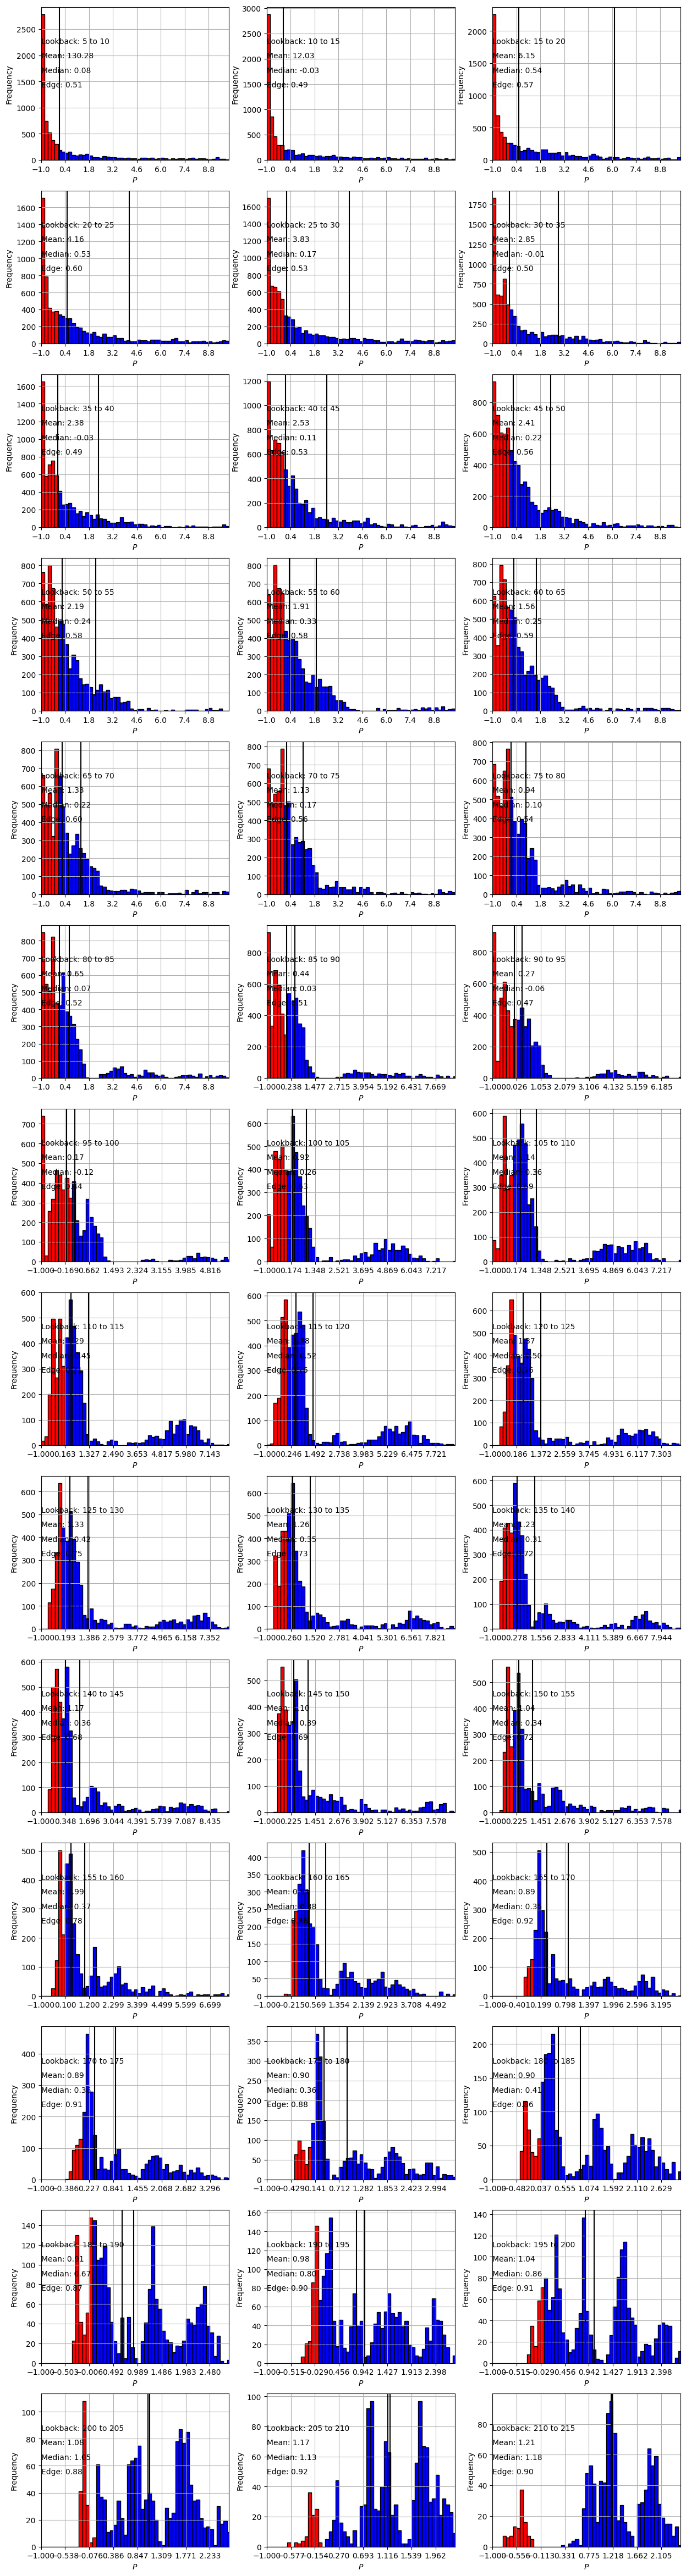

In [27]:
fig, axes = plt.subplots(14, 3, figsize=(15, 60))
medians = [np.median(PDS[k]) for k in PDS]
means = [np.mean(PDS[k]) for k in PDS]
edges = [(np.array(PDS[k]) > 0).sum() / len(PDS[k]) for k in PDS]
edge_min, edge_max = np.max(edges), np.max(edges)
median_min, median_max = np.min(medians), np.max(medians)
mean_min, mean_max = np.min(means), np.max(means)
for i in range(14):
  for j in range(3):
    k = i * 3 + j + 1
    bins = np.linspace(-1, min(10, np.max(PDS[k]) * 1.01), 56)
    # bins = np.linspace(-1, 1, 21)
    x, y, z = axes[i][j].hist(PDS[k], bins=bins, edgecolor='black')
    for l in range(len(z)):
      if bins[l] < 0:
        z[l].set_facecolor("r")
      else:
        z[l].set_facecolor("b")

    c_mean = "b" if means[k - 1] == mean_max else ("r" if means[k - 1] == mean_min else "k")
    c_median = "b" if medians[k - 1] == median_max else ("r" if medians[k - 1] == median_min else "k")
    c_edge = "b" if edges[k - 1] == edge_max else ("r" if edges[k - 1] == edge_min else "k")

    axes[i][j].axvline(np.median(PDS[k]), color="k")
    axes[i][j].axvline(np.mean(PDS[k]), color="k")
    axes[i][j].text(bins[0], 0.8 * x.max(), f"Lookback: {5 * k} to {5 * (k + 1)}")
    axes[i][j].text(bins[0], 0.5 * x.max(), f"Edge: {edges[k - 1]:.2f}", color=c_edge)
    axes[i][j].text(bins[0], 0.7 * x.max(), f"Mean: {means[k - 1]:.2f}", color=c_mean)
    axes[i][j].text(bins[0], 0.6 * x.max(), f"Median: {medians[k - 1]:.2f}", color=c_median)
    axes[i][j].set_xticks(bins[::7])
    axes[i][j].set_ylabel("Frequency")
    axes[i][j].set_xlabel("$P$")
    # axes[i][j].set_xlabel("$\rho$")
    axes[i][j].set_xlim(-1, min(10, np.max(PDS[k])))
    axes[i][j].grid()
plt.show()


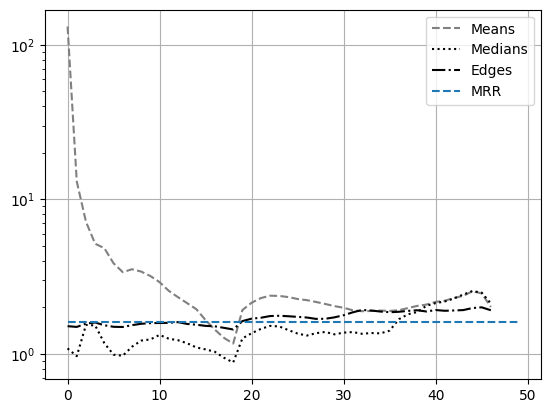

In [28]:
plt.plot(1 + np.array(means), "--", color='gray', label="Means")
plt.plot(1 + np.array(medians), ":", color="black", label="Medians")
plt.plot(1 + np.array(edges), "-.", color="black", label="Edges")
plt.plot(1.04 ** 12 * np.ones(len(edges)), "--", label="MRR")
plt.yscale("log")
plt.grid()
plt.legend()
plt.show()

/tmp/ipython-input-3451421345.py:4: RuntimeWarning: invalid value encountered in scalar divide
  edges = [(np.array(PSD[k]) > 0).sum() / len(PSD[k]) for k in PSD]


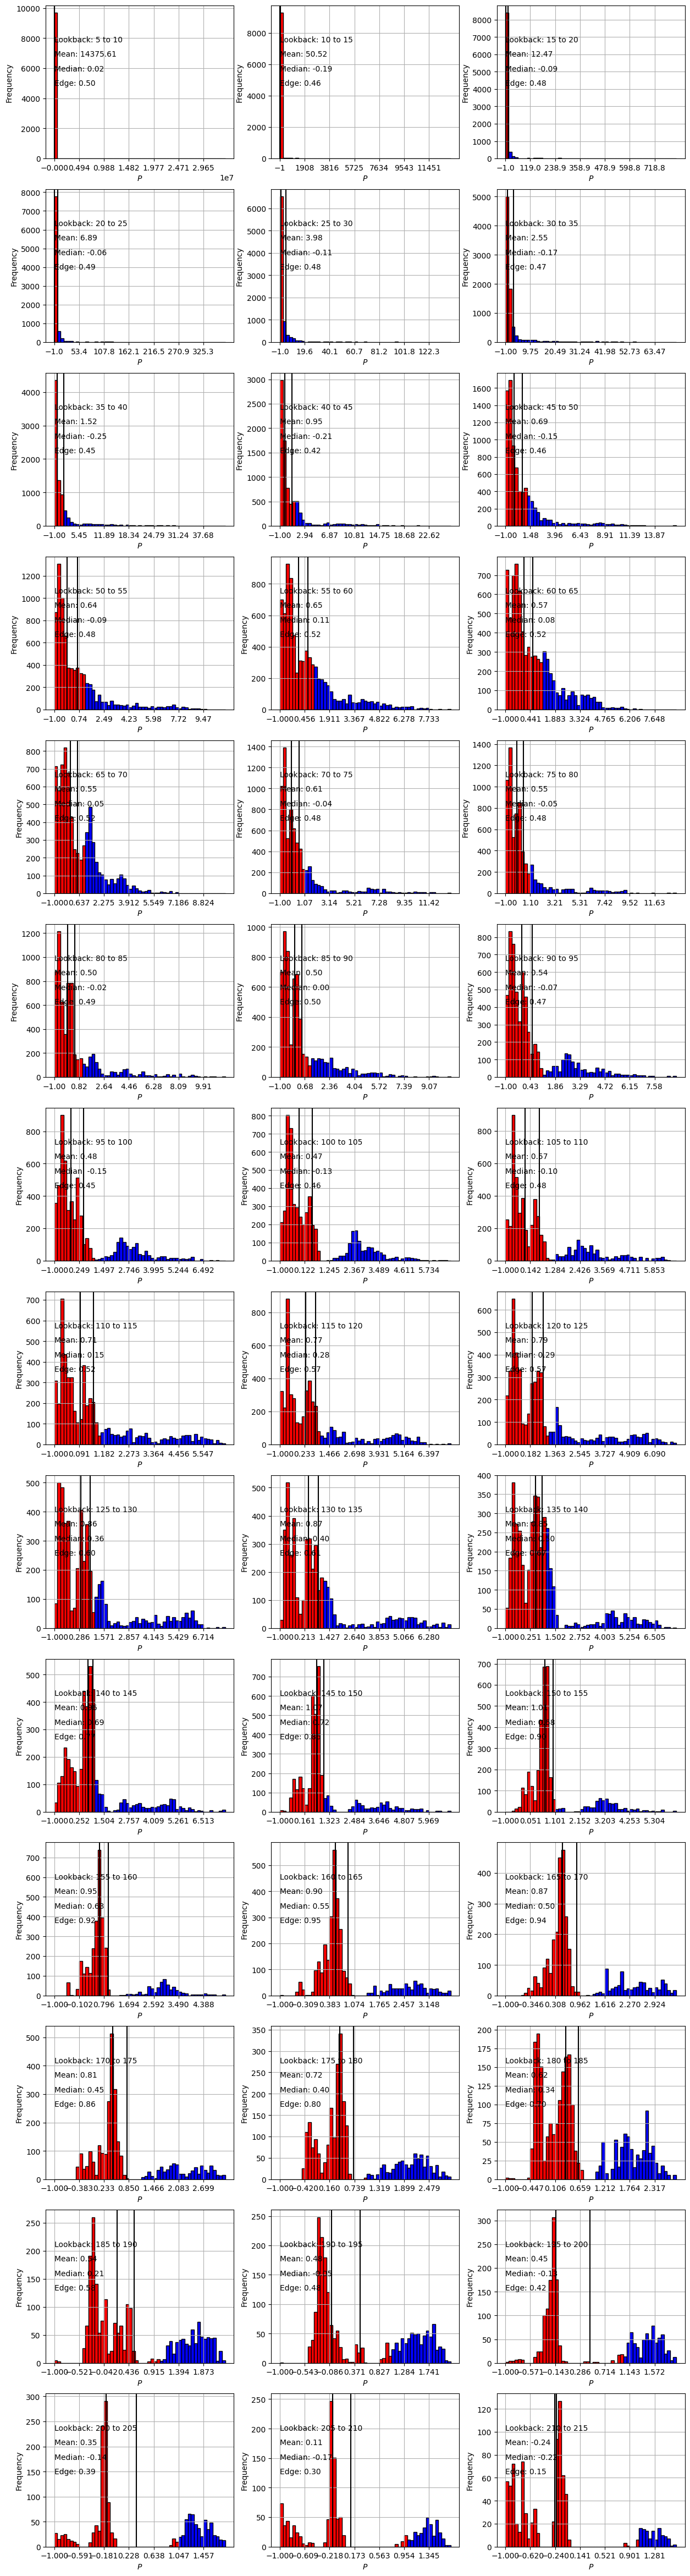

In [29]:
fig, axes = plt.subplots(14, 3, figsize=(15, 60))
medians = [np.median(PSD[k]) for k in PSD]
means = [np.mean(PSD[k]) for k in PSD]
edges = [(np.array(PSD[k]) > 0).sum() / len(PSD[k]) for k in PSD]
edge_min, edge_max = np.max(edges), np.max(edges)
median_min, median_max = np.min(medians), np.max(medians)
mean_min, mean_max = np.min(means), np.max(means)
for i in range(14):
  for j in range(3):
    k = i * 3 + j + 1
    bins = np.linspace(-1, max(1, np.max(PSD[k]) * 1.01), 56)
    # bins = np.linspace(-1, 1, 21)
    x, y, z = axes[i][j].hist(PSD[k], bins=bins, edgecolor='black')
    for l in range(len(z)):
      if bins[l] < 1:
        z[l].set_facecolor("r")
      else:
        z[l].set_facecolor("b")

    c_mean = "b" if means[k - 1] == mean_max else ("r" if means[k - 1] == mean_min else "k")
    c_median = "b" if medians[k - 1] == median_max else ("r" if medians[k - 1] == median_min else "k")
    c_edge = "b" if edges[k - 1] == edge_max else ("r" if edges[k - 1] == edge_min else "k")

    axes[i][j].axvline(np.median(PSD[k]), color="k")
    axes[i][j].axvline(np.mean(PSD[k]), color="k")
    axes[i][j].text(bins[0], 0.8 * x.max(), f"Lookback: {5 * k} to {5 * (k + 1)}")
    axes[i][j].text(bins[0], 0.5 * x.max(), f"Edge: {edges[k - 1]:.2f}", color=c_edge)
    axes[i][j].text(bins[0], 0.7 * x.max(), f"Mean: {means[k - 1]:.2f}", color=c_mean)
    axes[i][j].text(bins[0], 0.6 * x.max(), f"Median: {medians[k - 1]:.2f}", color=c_median)
    axes[i][j].set_xticks(bins[::8])
    axes[i][j].set_ylabel("Frequency")
    axes[i][j].set_xlabel("$P$")
    # axes[i][j].set_xlabel("$\rho$")
    # axes[i][j].set_xlim(0, max(10, np.max(PSD[k])))
    axes[i][j].grid()
plt.show()


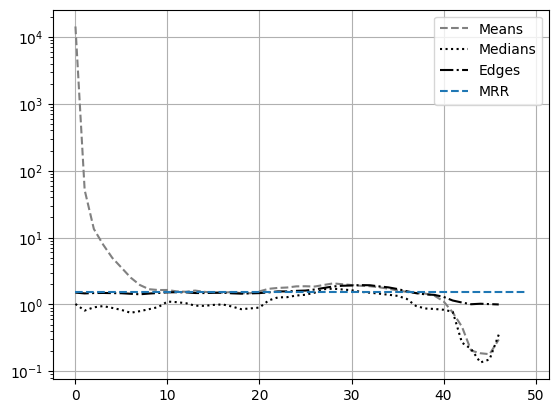

In [30]:
plt.plot(1 + np.array(means), "--", color='gray', label="Means")
plt.plot(1 + np.array(medians), ":", color="black", label="Medians")
plt.plot(1 + np.array(edges), "-.", color="black", label="Edges")
plt.plot(1.035 ** 12 * np.ones(len(edges)), "--", label="MRR")
plt.yscale("log")
plt.grid()
plt.legend()
plt.show()